# Test Performance Analysis
In this notebook, we analyze the performance of the selected models on the test dataset and account for trading costs on rebalancing.

#### Setup

In [18]:
# All imports
import sys
from pathlib import Path

# Get the absolute path of the directory one level up
root_dir = Path.cwd().parent

# Add it to sys.path if it's not already there
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

import os
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import plotly.graph_objects as go
from src.utils.io import load_path_config, load_json
from src.data_processing.loading import load_csv_files, ArtifactDataExtractor
from src.utils.constants import EQ_WT_NAME, SP500_NAME

from src.models.registry import NNModelLibrary

In [ ]:
paths_config = load_path_config(os.path.join('../config', 'paths.json'))

# Convert str paths to Path
artifacts_paths = {}
for name, path in paths_config['artifacts'].items():
    dir_path = Path('../'+ path)
    artifacts_paths[name] = dir_path

# Registering all NN models to the library
NNModelLibrary.autodiscover('src.models') # MUST be executed for model registration

#### Loading Validation Set Performance and Hyperparameters

In [9]:
grid_mode = 'one_model'
model_name = None
loss_name = None # Change previous grid mode if needed

extractor = ArtifactDataExtractor(grid_mode, artifacts_paths)

if grid_mode == 'one_model':
    # Get all models from library
    all_models = []
    for cat in NNModelLibrary.list_categories():
        all_models.extend(NNModelLibrary.list_models(cat))

    val_avg_perf = extractor.agg_avg_perf('avg_perf', all_models)
    opti_hparams = extractor.agg_opti_hparams('optimized', all_models)
    # all_daily_rets = extractor.agg_daily_rets('daily_rets', all_models)

    #### Remove custom losses 13 and 14 ####
    # mask = all_avg_perf.index.str.contains('-custom_loss_13|-custom_loss_14')
    # all_avg_perf = all_avg_perf[~mask]
    
elif grid_mode == 'one' and model_name is not None and loss_name is not None:
    opti_hparams = extractor.agg_opti_hparams(
        'optimized', [f'{model_name}-{loss_name}']
    )

AVG_PERF file for DeformTime not found at DeformTime. Skipping!
OPTIMIZED file for DeformTime not found at DeformTime. Skipping!


#### Loading Test Set Performance

In [25]:
# Average Performance across all metrics for all tested models
test_avg_perf = load_csv_files(
    {'avg_test_perf': artifacts_paths['test_perf_dir'] / 'avg_test_perf_all.csv'}
)['avg_test_perf']

# Daily returns for all models at all steps
test_returns = load_json(artifacts_paths['test_perf_dir'] / 'test_performance_all.json')

test_avg_perf

,compunded_return,sharpe,sortino,max_drawdown,cvar,omega,calmar
AttentionLSTM-custom_loss_10,0.032325,0.033875,0.066975,-0.136562,-0.039137,1.120825,0.008650
NaiveMVP,-0.010700,-0.024725,-0.028712,-0.084675,-0.019662,0.958125,-0.000975
GlobalMinimumVariance,-0.010700,-0.024725,-0.028712,-0.084675,-0.019662,0.958125,-0.000975
MeanVariancePortfolio,-0.047037,-0.043500,-0.071112,-0.156463,-0.034100,0.919575,-0.002475
HierarchialRiskParity,-0.008875,-0.009925,-0.004275,-0.087700,-0.020313,0.991750,0.001162
NestedClusteredOptimization,0.000200,-0.003612,-0.008613,-0.081800,-0.019938,1.005000,0.000138
Equal_Weight,-0.011262,-0.009038,-0.001388,-0.095187,-0.022625,0.993425,0.002025
S&P500,-0.003225,0.021125,0.048837,-0.091500,-0.023213,1.087338,0.008900


<Axes: title={'center': 'Mean Sharpe vs Portfolio Optimizer'}>

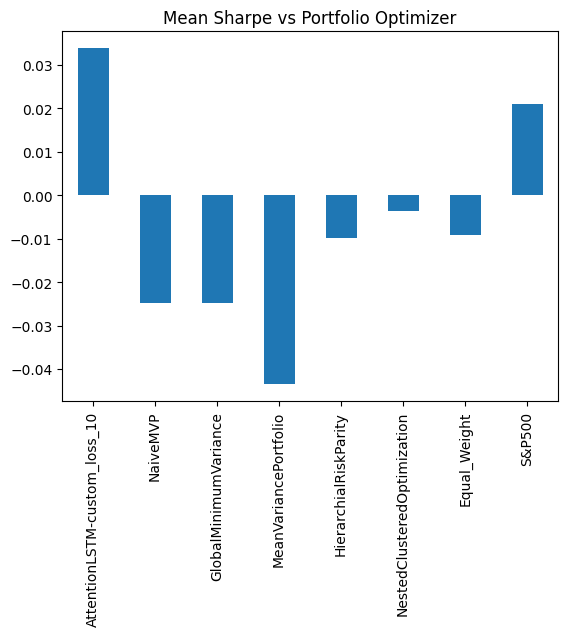

In [26]:
test_avg_perf['sharpe'].plot.bar(title='Mean Sharpe vs Portfolio Optimizer')

## Accounting for Trading Costs

Since our rebalance is done at the start of a quarter (60 trading days ~ 1 quarter)
- Explicit costs (Commision and Fees): For a retail long strategy (Investing more than 1 day), this is now effectively 0% for U.S. stocks.
- Implicit costs (Bid-Ask Spread): The quoted price of a stock is the midpoint. We buy at the "ask" and sell at the "bid.

The Bid-Ask Spread cost is applied to the first trading day of every window (the day the rebalancing happens).


In [39]:
empty_BA_spread = 0 #### TODO: Load features data from test split and plug in relevant BA_Spread #### THIS MUST BE FIXED

net_performance = {}
for model, windows_dict in test_returns.items():
    if model in [EQ_WT_NAME, SP500_NAME]:
        # Equal weight and S&P500 (ignoring rebalancing with index ETF or mutual funds) will not have rebalancing costs.
        continue
    else:
        net_performance.setdefault(model, {})
        prev_weights = None
        for window_dt_range, window_perf in windows_dict.items():
            returns = window_perf['returns']
            weights = window_perf['weights']

            if prev_weights:
                cost_per_step = sum([a - b for a, b in zip(weights, prev_weights)]) * (empty_BA_spread / 2)
            else:
                # For first step.
                cost_per_step = sum(weights) * (empty_BA_spread / 2)
            
            net_rets = returns.copy()
            net_rets[0] = net_rets[0] - cost_per_step
            net_performance[model][window_dt_range] = {
                'net_returns': net_rets,
                'weights': weights
            }

            prev_weights = weights

print(net_performance)

{'AttentionLSTM-custom_loss_10': {'2022-01-03_2022-03-29': {'net_returns': [0.0034703897622396463, 0.032333344005564785, 0.010958664586670379, -0.002039731808142386, -0.007341053398932505, -0.01906301722843651, 0.00966008813625586, 0.02050056160941007, -0.0020426843280033193, -0.00015152723131890526, -0.028491566420785874, -0.01940009740494544, -0.028873635706787346, -0.06319192165228577, 0.023587462952616975, -0.010361673108833203, -0.01186814113196716, 0.008771854783100774, 0.00966805426281123, 0.015048527298121946, 0.02249024988309125, 0.015205122739065206, -0.006475638319558377, 0.008973544694822224, -0.0035959896708745807, 0.027106147427553545, 0.019737212774072945, -0.013943699601095547, -0.013675794470549268, 0.00347058160003065, 0.03207922584178584, 0.006616321437488717, -0.025153920950307423, 0.00556839868450127, -0.014707728925114558, -0.021642639812746986, 0.0037225283267529156, 0.061990360878303216, 0.003230135950107623, -0.022664645126389337, 0.041368934847021074, 0.006381